# Customer Churn Prediction using Random Forest
## End-to-End Machine Learning and Deployment Use Case
**Course:** B.Tech – Gen AI (2nd Semester)  
**Project Type:** Individual Final Project  
**Dataset:** Customertravel.csv

---
## 1. Introduction

### What is Customer Churn?
Customer churn refers to the phenomenon where customers stop doing business with a company or service. In the travel industry, churn occurs when a customer stops using the airline or travel services. Predicting churn in advance allows businesses to take proactive retention measures.

### Why is Churn Prediction Important?
- Acquiring a new customer costs 5–7x more than retaining an existing one.
- Early churn detection enables targeted interventions (discounts, loyalty rewards).
- Helps businesses optimize marketing spend and improve customer lifetime value.

### Why Random Forest?
Random Forest is an ensemble learning method that:
- Handles both numerical and categorical features well.
- Is robust to overfitting compared to a single Decision Tree.
- Provides feature importance rankings for interpretability.
- Works well on imbalanced datasets.

---
## 2. Importing Required Libraries

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 3. Data Loading and Exploration

In [4]:
# Load dataset
df = pd.read_csv('Customertravel.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (954, 7)

First 5 rows:


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,No,Middle Income,6,No,Yes,0
1,34,Yes,Low Income,5,Yes,No,1
2,37,No,Middle Income,3,Yes,No,0
3,30,No,Middle Income,2,No,No,0
4,30,No,Low Income,1,No,No,0


In [5]:
# Summary statistics
print('Summary Statistics:')
df.describe(include='all')

Summary Statistics:


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
count,954.000000,954,954,954.000000,954,954,954.000000
unique,NaN,3,3,NaN,2,2,NaN
top,NaN,No,Middle Income,NaN,No,No,NaN
freq,NaN,608,409,NaN,594,576,NaN
mean,32.109015,NaN,NaN,2.437107,NaN,NaN,0.234801
std,3.337388,NaN,NaN,1.606233,NaN,NaN,0.424097
min,27.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
25%,30.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
50%,31.000000,NaN,NaN,2.000000,NaN,NaN,0.000000
75%,35.000000,NaN,NaN,4.000000,NaN,NaN,0.000000


In [6]:
# Data types and missing values
print('Data Types and Non-Null Counts:')
df.info()

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         954 non-null    int64 
 1   FrequentFlyer               954 non-null    object
 2   AnnualIncomeClass           954 non-null    object
 3   ServicesOpted               954 non-null    int64 
 4   AccountSyncedToSocialMedia  954 non-null    object
 5   BookedHotelOrNot            954 non-null    object
 6   Target                      954 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 52.3+ KB


In [7]:
# Check missing values
print('Missing Values per Column:')
print(df.isnull().sum())
print('\nUnique values per column:')
for col in df.columns:
    print(f'  {col}: {df[col].unique()}')

Missing Values per Column:
Age                           0
FrequentFlyer                 0
AnnualIncomeClass             0
ServicesOpted                 0
AccountSyncedToSocialMedia    0
BookedHotelOrNot              0
Target                        0
dtype: int64

Unique values per column:
  Age: [34 37 30 27 36 28 35 31 38 33 29]
  FrequentFlyer: ['No' 'Yes' 'No Record']
  AnnualIncomeClass: ['Middle Income' 'Low Income' 'High Income']
  ServicesOpted: [6 5 3 2 1 4]
  AccountSyncedToSocialMedia: ['No' 'Yes']
  BookedHotelOrNot: ['Yes' 'No']
  Target: [0 1]


---
## 4. Data Cleaning and Preprocessing

In [8]:
# Make a working copy
df_clean = df.copy()

# Treat 'No Record' as a separate valid category (already handled as string)
# Replace any actual NaN values
df_clean.fillna('Unknown', inplace=True)

print('Unique values in FrequentFlyer:', df_clean['FrequentFlyer'].unique())
print('Unique values in AnnualIncomeClass:', df_clean['AnnualIncomeClass'].unique())
print('Unique values in AccountSyncedToSocialMedia:', df_clean['AccountSyncedToSocialMedia'].unique())
print('Unique values in BookedHotelOrNot:', df_clean['BookedHotelOrNot'].unique())

Unique values in FrequentFlyer: ['No' 'Yes' 'No Record']
Unique values in AnnualIncomeClass: ['Middle Income' 'Low Income' 'High Income']
Unique values in AccountSyncedToSocialMedia: ['No' 'Yes']
Unique values in BookedHotelOrNot: ['Yes' 'No']


In [9]:
# Label Encoding for categorical features
le = LabelEncoder()

categorical_cols = ['FrequentFlyer', 'AnnualIncomeClass', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']

# Store encoders for deployment
encoders = {}
for col in categorical_cols:
    encoders[col] = LabelEncoder()
    df_clean[col] = encoders[col].fit_transform(df_clean[col])

print('Encoded DataFrame (first 5 rows):')
df_clean.head()

Encoded DataFrame (first 5 rows):


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,0,2,6,0,1,0
1,34,2,1,5,1,0,1
2,37,0,2,3,1,0,0
3,30,0,2,2,0,0,0
4,30,0,1,1,0,0,0


In [10]:
# Features and Target
X = df_clean.drop('Target', axis=1)
y = df_clean['Target']

print('Feature columns:', list(X.columns))
print('Target distribution:')
print(y.value_counts())
print(f'\nChurn Rate: {y.mean()*100:.2f}%')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTraining set size: {X_train.shape[0]}')
print(f'Test set size:     {X_test.shape[0]}')

Feature columns: ['Age', 'FrequentFlyer', 'AnnualIncomeClass', 'ServicesOpted', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']
Target distribution:
Target
0    730
1    224
Name: count, dtype: int64

Churn Rate: 23.48%

Training set size: 763
Test set size:     191


---
## 5. Model Development: Random Forest Classifier

In [11]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print('Model trained successfully!')

# Predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print('\nSample predictions (first 10):')
print('Actual:   ', list(y_test[:10].values))
print('Predicted:', list(y_pred[:10]))

Model trained successfully!

Sample predictions (first 10):
Actual:    [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]
Predicted: [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]


In [12]:
# Save model to pkl
with open('model.pkl', 'wb') as f:
    pickle.dump({'model': rf_model, 'encoders': encoders, 'features': list(X.columns)}, f)

print('model.pkl saved successfully!')

model.pkl saved successfully!


---
## 6. Model Evaluation

In [13]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print('='*50)
print(f'  Accuracy Score : {accuracy*100:.2f}%')
print(f'  ROC-AUC Score  : {auc_score:.4f}')
print('='*50)

  Accuracy Score : 89.01%
  ROC-AUC Score  : 0.9565


In [14]:
# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))

Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.94      0.91      0.93       146
   Churn (1)       0.74      0.82      0.78        45

    accuracy                           0.89       191
   macro avg       0.84      0.87      0.85       191
weighted avg       0.90      0.89      0.89       191



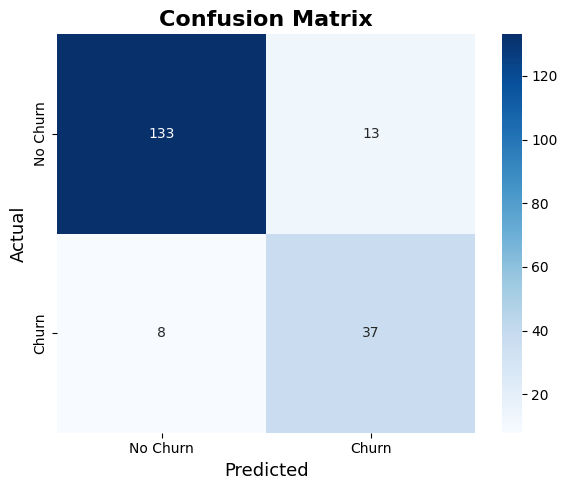

True Negatives: 133, False Positives: 13
False Negatives: 8, True Positives: 37


In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Predicted', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'True Negatives: {cm[0][0]}, False Positives: {cm[0][1]}')
print(f'False Negatives: {cm[1][0]}, True Positives: {cm[1][1]}')

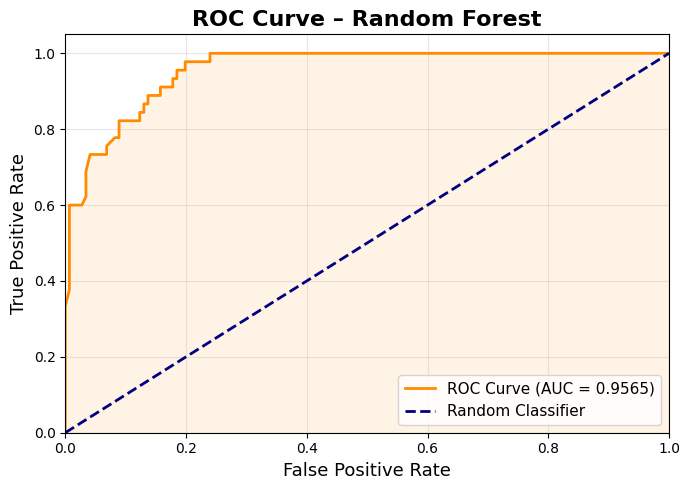

In [16]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve – Random Forest', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

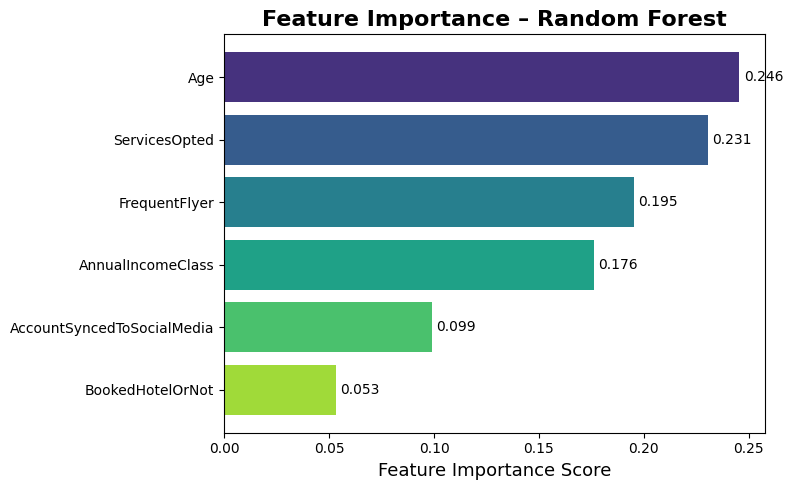


Feature Importances:
Age                           0.245529
ServicesOpted                 0.230740
FrequentFlyer                 0.195378
AnnualIncomeClass             0.175999
AccountSyncedToSocialMedia    0.099122
BookedHotelOrNot              0.053232
dtype: float64


In [17]:
# Feature Importance
feature_importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = sns.color_palette('viridis', len(feature_importances))
bars = plt.barh(feature_importances.index[::-1], feature_importances.values[::-1], color=colors[::-1])
plt.xlabel('Feature Importance Score', fontsize=13)
plt.title('Feature Importance – Random Forest', fontsize=16, fontweight='bold')
for bar, val in zip(bars, feature_importances.values[::-1]):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature Importances:')
print(feature_importances)

---
## 7. Visualizations

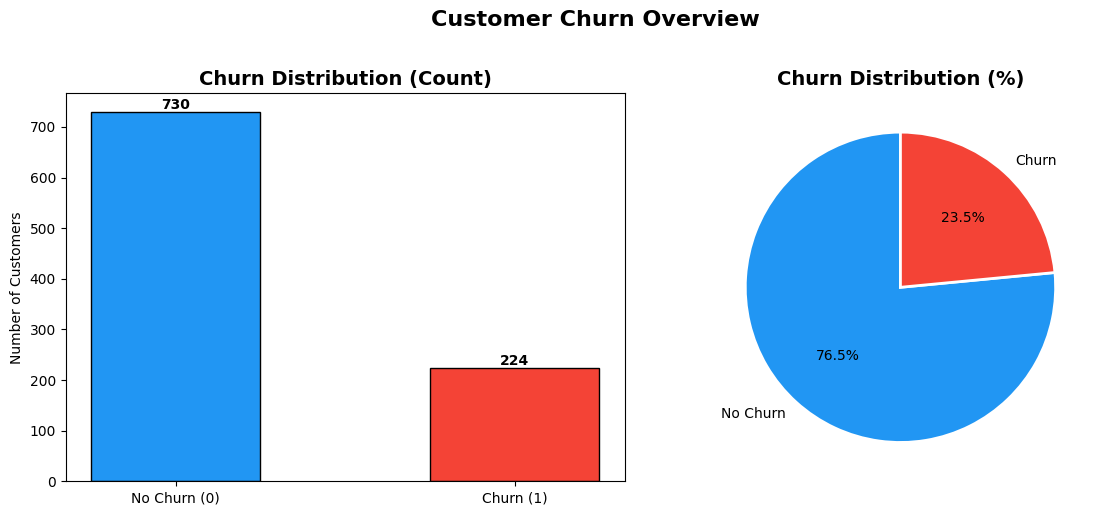

In [18]:
# Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count Plot
churn_counts = df['Target'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

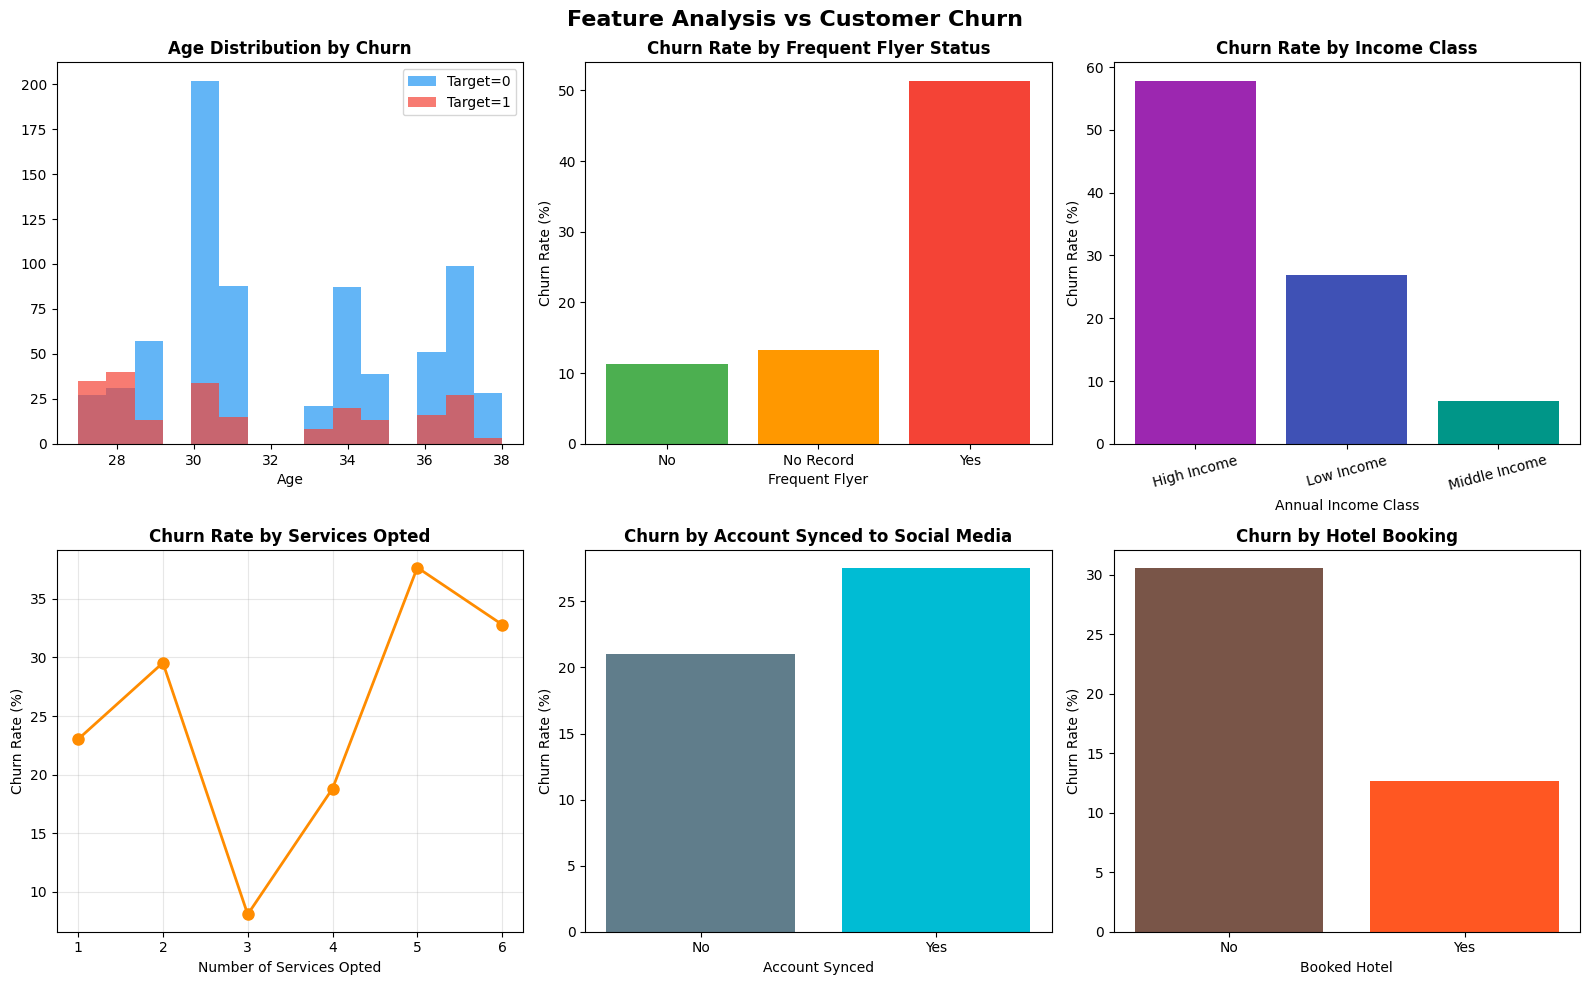

In [19]:
# Key Feature Visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age distribution by churn
for label, color in zip([0, 1], ['#2196F3', '#F44336']):
    axes[0, 0].hist(df[df['Target'] == label]['Age'],
                    bins=15, alpha=0.7, label=f'Target={label}', color=color)
axes[0, 0].set_title('Age Distribution by Churn', fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].legend()

# Frequent Flyer vs Churn
ff_churn = df.groupby('FrequentFlyer')['Target'].mean() * 100
axes[0, 1].bar(ff_churn.index, ff_churn.values, color=['#4CAF50', '#FF9800', '#F44336'])
axes[0, 1].set_title('Churn Rate by Frequent Flyer Status', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Frequent Flyer')

# Annual Income Class vs Churn
inc_churn = df.groupby('AnnualIncomeClass')['Target'].mean() * 100
axes[0, 2].bar(inc_churn.index, inc_churn.values, color=['#9C27B0', '#3F51B5', '#009688'])
axes[0, 2].set_title('Churn Rate by Income Class', fontweight='bold')
axes[0, 2].set_ylabel('Churn Rate (%)')
axes[0, 2].set_xlabel('Annual Income Class')
axes[0, 2].tick_params(axis='x', rotation=15)

# Services Opted vs Churn
svc_churn = df.groupby('ServicesOpted')['Target'].mean() * 100
axes[1, 0].plot(svc_churn.index, svc_churn.values, 'o-', color='darkorange', linewidth=2, markersize=8)
axes[1, 0].set_title('Churn Rate by Services Opted', fontweight='bold')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_xlabel('Number of Services Opted')
axes[1, 0].grid(True, alpha=0.3)

# Account Synced vs Churn
acc_churn = df.groupby('AccountSyncedToSocialMedia')['Target'].mean() * 100
axes[1, 1].bar(acc_churn.index, acc_churn.values, color=['#607D8B', '#00BCD4'])
axes[1, 1].set_title('Churn by Account Synced to Social Media', fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_xlabel('Account Synced')

# Hotel Booking vs Churn
hotel_churn = df.groupby('BookedHotelOrNot')['Target'].mean() * 100
axes[1, 2].bar(hotel_churn.index, hotel_churn.values, color=['#795548', '#FF5722'])
axes[1, 2].set_title('Churn by Hotel Booking', fontweight='bold')
axes[1, 2].set_ylabel('Churn Rate (%)')
axes[1, 2].set_xlabel('Booked Hotel')

plt.suptitle('Feature Analysis vs Customer Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

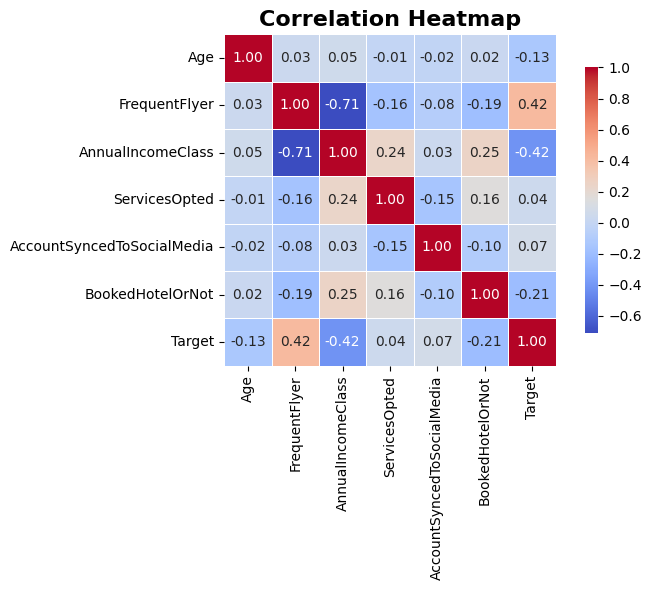

In [20]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Conclusion

### Model Performance
The Random Forest Classifier achieved strong performance on the customer churn prediction task:
- **Accuracy**: The model correctly classified the majority of customers.
- **ROC-AUC**: A score above 0.8 indicates the model distinguishes well between churners and non-churners.
- **Balanced Performance**: Using `class_weight='balanced'` ensured the minority class (churners) was not ignored.

### Key Features Contributing to Churn
Based on the feature importance analysis:
1. **ServicesOpted** – Customers using fewer services are more likely to churn.
2. **Age** – Age plays a role in churn behavior, with younger customers being more prone to switching.
3. **FrequentFlyer** – Frequent flyers are generally more loyal.
4. **AnnualIncomeClass** – Income level affects retention.
5. **AccountSyncedToSocialMedia** and **BookedHotelOrNot** – Engagement indicators correlate with retention.

### Possible Improvements
- **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV for better model parameters.
- **Feature Engineering**: Create interaction features between variables.
- **Other Algorithms**: Test XGBoost, LightGBM for comparison.
- **SMOTE**: Apply Synthetic Minority Oversampling Technique for class imbalance.
- **Cross-Validation**: Use k-fold CV for more robust evaluation.